In [1]:
import torch
import torch.nn as nn
import torch.linalg as la
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os
import requests
import tarfile
from PIL import Image
import sys
import hydra
from omegaconf import OmegaConf

# Add the project source directory to the Python path
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from src.data.dataset import load_mnist
from src.utils.losses import compute_logits
from src.train import get_target_distributions
from src.utils.evaluation import (
    get_all_predictions,
    get_classification_report_and_cm,
    calculate_ece_and_reliability_diagram,
    calculate_brier_score,
    get_ood_confidences_and_plot,
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

/home/e1444/repos/dnf/ENV/lib/python3.11/site-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/home/e1444/repos/dnf/ENV/lib/python3.11/site-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated

Using device: cuda


In [2]:
# ----------------------------
# Configuration
# ----------------------------
# Define the configuration structure and load the files in a Hydra-like way
conf_path = os.path.join(project_root, 'conf')

# Start with the base config, which may contain defaults or other top-level settings
cfg = OmegaConf.load(os.path.join(conf_path, 'config.yaml'))

# Define which specific configs to load for this run
# This makes it easy to switch models or datasets later
model_config_name = "dglow_resnet.yaml" 
data_config_name = "mnist.yaml"
training_config_name = "default.yaml"

# Create a structured config by merging the components
cfg = OmegaConf.merge(
    cfg,
    {
        "model": OmegaConf.load(os.path.join(conf_path, 'model', model_config_name)),
        "data": OmegaConf.load(os.path.join(conf_path, 'data', data_config_name)),
        "training": OmegaConf.load(os.path.join(conf_path, 'training', training_config_name)),
    }
)

In [21]:
# ----------------------------
# Data Loading
# ----------------------------
# The load_mnist function from the project returns DataLoaders.
# We need the underlying dataset for some evaluation metrics.
cfg.data.dataset.path = os.path.join(project_root, cfg.data.dataset.path)
cfg.data.dataset.num_workers = 1
train_loader, test_loader = load_mnist(cfg.data)
test_dataset = test_loader.dataset

print(f"Loaded MNIST test dataset with {len(test_dataset)} samples.")

Loaded MNIST test dataset with 10000 samples.


In [18]:
# --- 1. Instantiate a new model ---
cfg.model.hidden_channels = 512
cfg.model.num_fixed_levels = 3
model = hydra.utils.instantiate(cfg.model, _convert_="partial").to(device)

# --- 2. Load the checkpoint file ---
# CHECKPOINT_PATH = "/home/e1444/scratch/dnf/logs/2025-11-19/23-05-29/checkpoint_epoch_105.pth" # best so far
CHECKPOINT_PATH = "/home/e1444/scratch/dnf/logs/2025-11-22/14-48-14/checkpoint_epoch_20.pth" # Specify

if not os.path.exists(CHECKPOINT_PATH):
    raise FileNotFoundError(f"Checkpoint file not found at '{CHECKPOINT_PATH}'. Please update the path.")

print(f"Loading checkpoint from {CHECKPOINT_PATH}...")
checkpoint = torch.load(CHECKPOINT_PATH, map_location=device)

# --- 3. Load the states into the new instances ---
model.load_state_dict(checkpoint['model_state_dict'])

# Load the trained means and variances for correct evaluation
latent_mu = checkpoint['latent_mu'].to(device)
latent_v = checkpoint['latent_v'].to(device)
latent_U = checkpoint['latent_U'].to(device)

# --- 4. Set the model to evaluation mode ---
model.eval()

print("Model loaded successfully and set to evaluation mode.")

Loading checkpoint from /home/e1444/scratch/dnf/logs/2025-11-22/14-48-14/checkpoint_epoch_20.pth...
Model loaded successfully and set to evaluation mode.


## 3. Evaluation Metrics
Now we compute the model's predictions on the test set and evaluate its performance across different metrics.

In [22]:
# Get model predictions for the entire test set
print("Computing model predictions on the test set...")
final_target_dists = get_target_distributions(latent_mu, latent_v, latent_U, cfg.training.num_classes)
y_true, y_pred, probabilities, confidences = get_all_predictions(
    model, test_loader, device, final_target_dists
)
print("Predictions computed.")

Computing model predictions on the test set...
Predictions computed.


In [28]:
x = test_dataset[0][0].to(device)
x = x.view(1, 1, 32, 32)
out = model(x)
log_dets = [x[1] for x in out]
log_dets

[tensor([0.0712], device='cuda:0', grad_fn=<CloneBackward0>),
 tensor([0.1656], device='cuda:0', grad_fn=<CloneBackward0>),
 tensor([1.6779], device='cuda:0', grad_fn=<CloneBackward0>),
 tensor([1.8876], device='cuda:0', grad_fn=<CloneBackward0>),
 tensor([2.8810], device='cuda:0', grad_fn=<CloneBackward0>),
 tensor([3.1470], device='cuda:0', grad_fn=<CloneBackward0>),
 tensor([3.1470], device='cuda:0', grad_fn=<CloneBackward0>),
 tensor([3.1470], device='cuda:0', grad_fn=<CloneBackward0>),
 tensor([3.1470], device='cuda:0', grad_fn=<CloneBackward0>),
 tensor([3.1470], device='cuda:0', grad_fn=<CloneBackward0>),
 tensor([3.1470], device='cuda:0', grad_fn=<CloneBackward0>),
 tensor([3.1470], device='cuda:0', grad_fn=<CloneBackward0>),
 tensor([3.1470], device='cuda:0', grad_fn=<CloneBackward0>),
 tensor([3.1470], device='cuda:0', grad_fn=<CloneBackward0>),
 tensor([3.1470], device='cuda:0', grad_fn=<CloneBackward0>),
 tensor([3.1470], device='cuda:0', grad_fn=<CloneBackward0>),
 tensor(

### 3.1. Classification Report & Confusion Matrix

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       980
           1       0.99      0.99      0.99      1135
           2       0.99      0.98      0.98      1032
           3       0.99      0.99      0.99      1010
           4       0.98      0.99      0.98       982
           5       0.99      0.98      0.99       892
           6       0.97      0.99      0.98       958
           7       0.98      0.99      0.99      1028
           8       1.00      0.98      0.99       974
           9       0.99      0.99      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



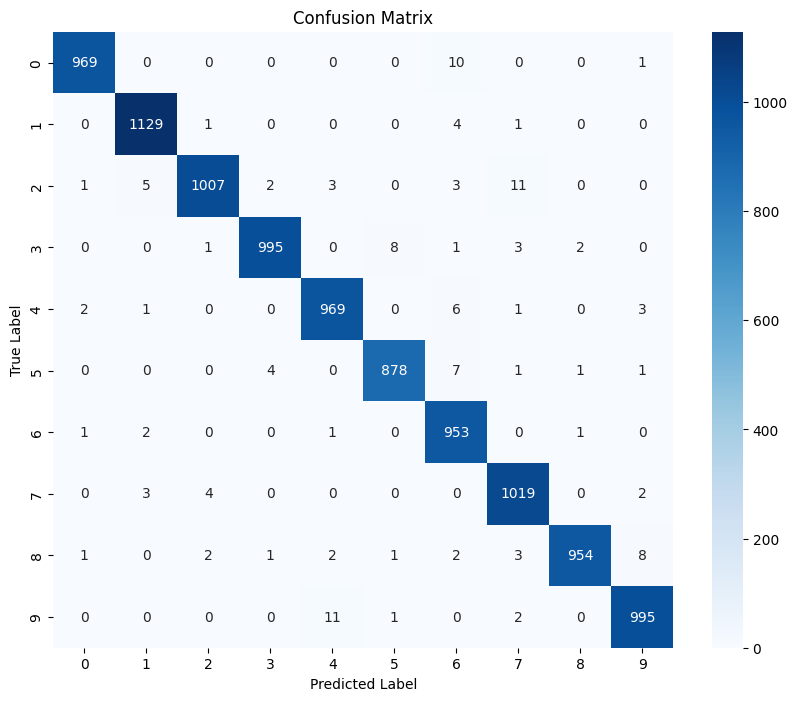

In [29]:
# Get classification report and confusion matrix
mnist_target_names = [str(i) for i in range(cfg.training.num_classes)]
_, _ = get_classification_report_and_cm(y_true, y_pred, mnist_target_names)

### 3.2. Model Calibration (ECE)
Expected Calibration Error measures the difference between a model's confidence and its accuracy. A lower ECE means the model is better calibrated.

Expected Calibration Error (ECE): 0.0069

--- Reliability Diagram Data ---
Confidence Bin Avg Confidence Accuracy    Gap  Samples
     0.00-0.05         0.0000   0.0000 0.0000        0
     0.05-0.10         0.0000   0.0000 0.0000        0
     0.10-0.15         0.0000   0.0000 0.0000        0
     0.15-0.20         0.0000   0.0000 0.0000        0
     0.20-0.25         0.0000   0.0000 0.0000        0
     0.25-0.30         0.0000   0.0000 0.0000        0
     0.30-0.35         0.0000   0.0000 0.0000        0
     0.35-0.40         0.3810   0.0000 0.3810        1
     0.40-0.45         0.4361   0.3333 0.1028        3
     0.45-0.50         0.4851   0.7500 0.2649        4
     0.50-0.55         0.5238   0.5385 0.0146       13
     0.55-0.60         0.5756   0.5714 0.0042       14
     0.60-0.65         0.6194   0.4545 0.1649       11
     0.65-0.70         0.6746   0.3333 0.3412        9
     0.70-0.75         0.7213   0.6250 0.0963       16
     0.75-0.80         0.7712   0.7391 0.0321

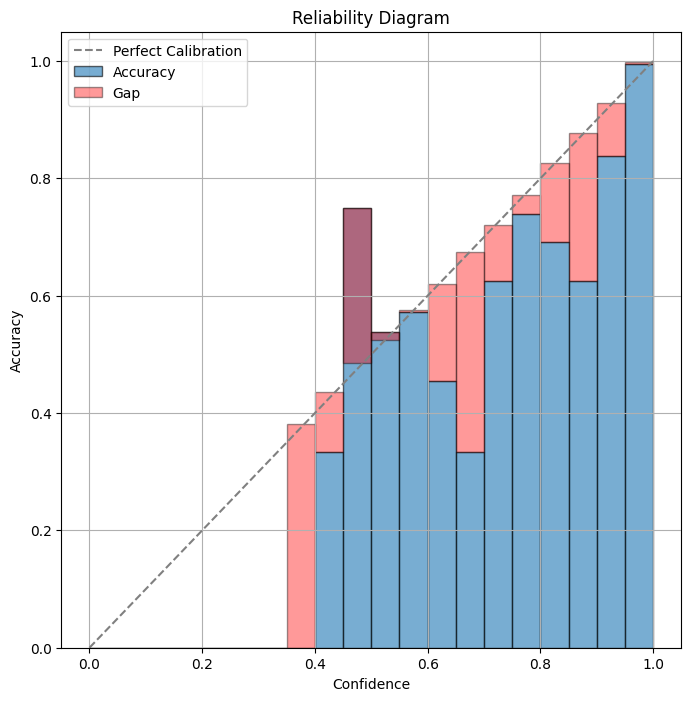

In [30]:
# Calculate ECE and plot reliability diagram
_ = calculate_ece_and_reliability_diagram(confidences, y_pred, y_true, n_bins=20)

### 3.3. NLL and Brier Score
These are proper scoring rules that measure the quality of the model's probabilistic predictions.

In [31]:
# Calculate NLL and Brier score
_ = calculate_brier_score(y_true, probabilities)

Multi-class Brier Score: 0.0222


### 3.4. Out-of-Distribution (OOD) Detection
Here, we test the model's confidence on a dataset it has never seen before (notMNIST). A well-behaved model should be less confident on OOD data compared to in-distribution data (MNIST).

In [ ]:
from torchvision import datasets, transforms

def get_notmnist_loader(batch_size=256):
    """Downloads, extracts, and creates a DataLoader for the notMNIST dataset."""
    root = './data'
    url = 'http://yaroslavvb.com/upload/notMNIST/notMNIST_small.tar.gz'
    filename = 'notMNIST_small.tar.gz'
    filepath = os.path.join(root, filename)
    extract_path = os.path.join(root, 'notMNIST_small')

    if not os.path.exists(extract_path):
        if not os.path.exists(root):
            os.makedirs(root)
        print(f"Downloading {url}...")
        try:
            headers = {'User-Agent': ''}
            r = requests.get(url, stream=True, timeout=30, headers=headers)
            r.raise_for_status()
            with open(filepath, 'wb') as f:
                for chunk in r.iter_content(chunk_size=8192):
                    f.write(chunk)
            print("Download complete.")
            print(f"Extracting {filepath}...")
            with tarfile.open(filepath, 'r:gz') as tar:
                tar.extractall(path=root)
            print("Extraction complete.")
            os.remove(filepath)
        except Exception as e:
            print(f"Failed to download or extract notMNIST: {e}")
            return None

    transform = transforms.Compose([
        transforms.Pad(padding=2),
        transforms.Grayscale(num_output_channels=1),
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))
    ])

    def is_valid_file(path):
        try:
            with Image.open(path) as img:
                img.verify()
            return True
        except Exception:
            return False

    try:
        notmnist_dataset = datasets.ImageFolder(root=extract_path, transform=transform, is_valid_file=is_valid_file)
        notmnist_loader = DataLoader(notmnist_dataset, batch_size=batch_size, shuffle=False)
        print(f"notMNIST loaded successfully with {len(notmnist_dataset)} valid images.")
        return notmnist_loader
    except Exception as e:
        print(f"Failed to create notMNIST loader: {e}")
        return None

notmnist_loader = get_notmnist_loader()


Computing confidences for out-of-distribution data (notMNIST)...


/home/e1444/repos/dnf/ENV/lib/python3.11/site-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 1, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
/home/e1444/repos/dnf/src/train.py:40: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  df = torch.tensor(self.df, device=value.device, dtype=value.dtype)


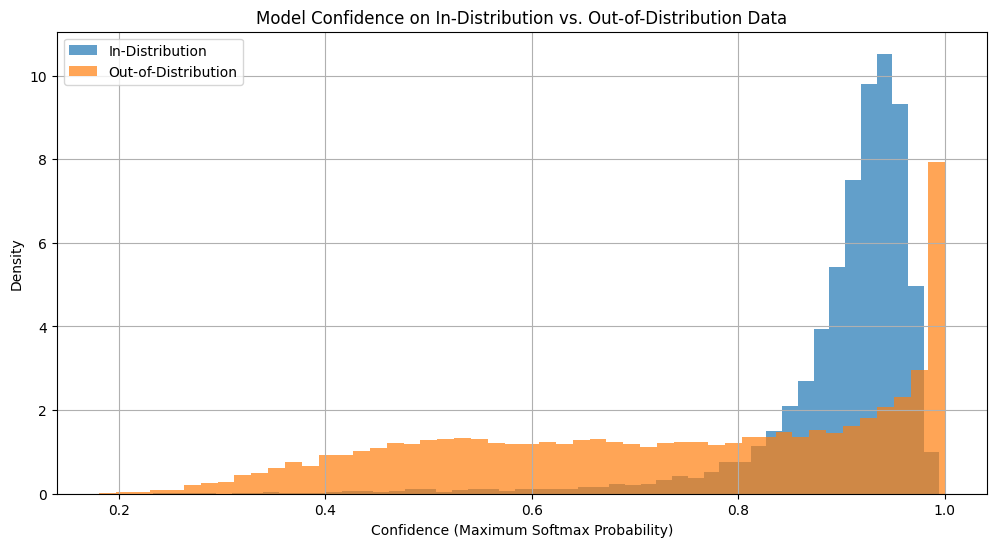

Average confidence on In-Distribution data: 0.9009
Average confidence on Out-of-Distribution data: 0.7322


In [30]:
# Get and plot OOD confidences
def get_ood_confidences_and_plot(model, in_dist_loader, out_dist_loader, device, target_dists):
    """
    Get and plot confidences for in-distribution vs out-of-distribution data.
    """
    model.eval()
    
    def get_confidences(loader):
        all_confs = []
        with torch.no_grad():
            for x_batch, _ in loader:
                x_batch = x_batch.to(device)
                intermediate_outputs = model(x_batch)
                z, log_det = intermediate_outputs[-1]
                z = z.view(z.size(0), -1)
                logits = compute_logits(z, log_det, target_dists)
                probabilities = torch.softmax(logits, dim=1)
                confidences, _ = torch.max(probabilities, 1)
                all_confs.append(confidences.cpu())
        return torch.cat(all_confs).numpy()

    in_dist_confs = get_confidences(in_dist_loader)
    out_dist_confs = get_confidences(out_dist_loader)

    plt.figure(figsize=(12, 6))
    plt.hist(in_dist_confs, bins=50, alpha=0.7, label='In-Distribution', density=True)
    plt.hist(out_dist_confs, bins=50, alpha=0.7, label='Out-of-Distribution', density=True)
    plt.title('Model Confidence on In-Distribution vs. Out-of-Distribution Data')
    plt.xlabel('Confidence (Maximum Softmax Probability)')
    plt.ylabel('Density')
    plt.legend()
    plt.grid(True)
    plt.show()

    print(f"Average confidence on In-Distribution data: {np.mean(in_dist_confs):.4f}")
    print(f"Average confidence on Out-of-Distribution data: {np.mean(out_dist_confs):.4f}")
    return in_dist_confs, out_dist_confs

if notmnist_loader:
    print("\nComputing confidences for out-of-distribution data (notMNIST)...")
    _, _ = get_ood_confidences_and_plot(
        model, test_loader, notmnist_loader, device, final_target_dists
    )
else:
    print("Could not run OOD analysis because notMNIST failed to load.")

Fitting PCA on combined data...

--- Statistics for Class 1 (PCA space) ---
Real mean: [-0.04657091 -0.04184102]
Gen mean:  [ 0.04333325 -0.02170151]
Real std:  [0.00883456 0.00885102]
Gen std:   [5.54380886 1.49382045]
Real MAD (Robust): [0.00564885 0.00550929]
Gen MAD (Robust):  [0.59639194 0.6503583 ]
MAD Ratio (Gen/Real): [105.57755331 118.04760714]

--- Statistics for Class 7 (PCA space) ---
Real mean: [-0.05233851 -0.04565987]
Gen mean:  [-0.02200091  0.04058711]
Real std:  [0.01315703 0.01347376]
Gen std:   [1.22273817 3.54644249]
Real MAD (Robust): [0.0078813  0.00843508]
Gen MAD (Robust):  [0.63065326 0.61429533]
MAD Ratio (Gen/Real): [80.01889706 72.82626019]


/tmp/ipykernel_1210201/2429888375.py:76: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', len(target_classes))


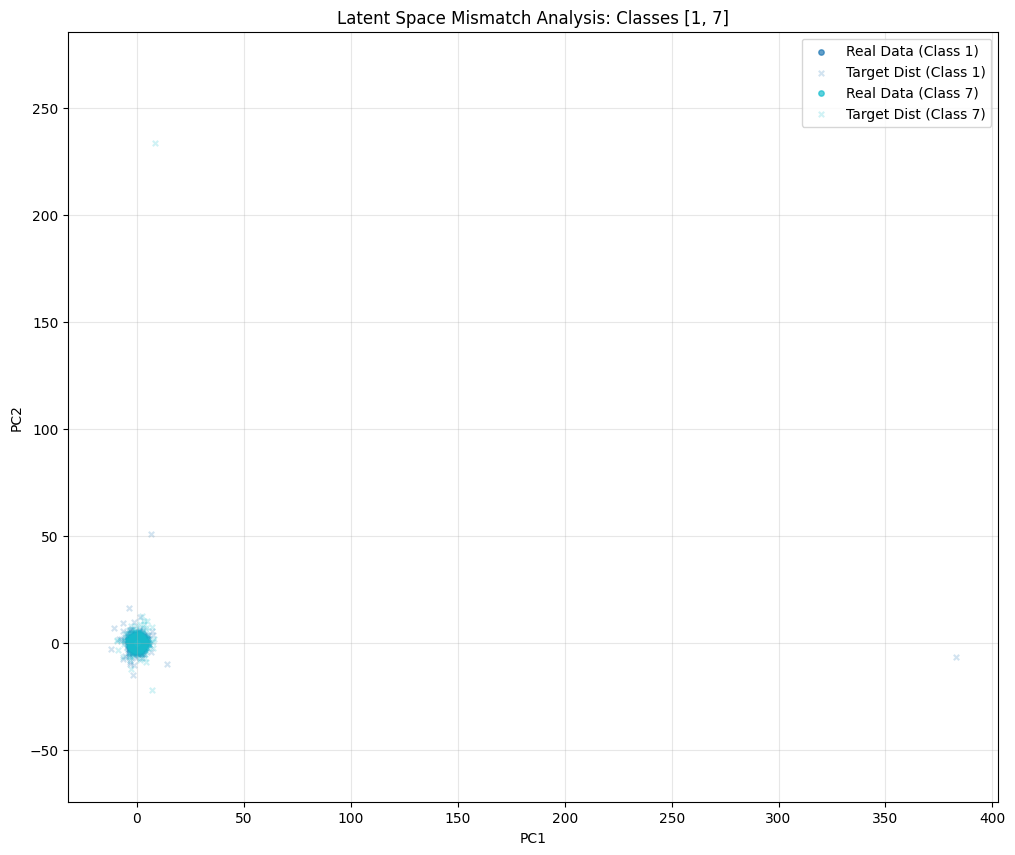

In [33]:
from sklearn.decomposition import PCA
import torch
import numpy as np
import matplotlib.pyplot as plt
from src.train import MultivariateLowRankStudentT

def visualize_latent_mismatch(model, data_loader, target_dists, device,
                              target_classes=[0, 1], num_samples_per_class=500):
    """
    Visualizes overlap or mismatch between actual latent embeddings of data
    and samples drawn from target distributions, for a list of classes.
    """
    model.eval()
    
    real_latents_by_class = {c: [] for c in target_classes}
    generated_latents_by_class = {c: [] for c in target_classes}
    samples_collected = {c: 0 for c in target_classes}

    print("Collecting real latent embeddings...")
    with torch.no_grad():
        for x_batch, y_batch in data_loader:
            for c in target_classes:
                if samples_collected[c] >= num_samples_per_class:
                    continue

                mask = y_batch == c
                if not mask.any():
                    continue

                x_class_batch = x_batch[mask].to(device)
                intermediate_outputs = model(x_class_batch)
                z, _ = intermediate_outputs[-1]
                z = z.view(z.size(0), -1)

                real_latents_by_class[c].append(z.cpu())
                samples_collected[c] += len(x_class_batch)

            if all(samples_collected[c] >= num_samples_per_class for c in target_classes):
                break

    # Finalize real latents and sample from target distributions
    all_real_latents = []
    all_generated_latents = []

    for c in target_classes:
        if not real_latents_by_class[c]:
            print(f"Warning: no real samples found for class {c}.")
            continue

        class_real = torch.cat(real_latents_by_class[c])[:num_samples_per_class]
        real_latents_by_class[c] = class_real
        all_real_latents.append(class_real)

        with torch.no_grad():
            # Sample from target distribution
            class_gen = target_dists[c].sample((num_samples_per_class,)).cpu()
            generated_latents_by_class[c] = class_gen
            all_generated_latents.append(class_gen)

    if not all_real_latents:
        print("No data collected for any class. Aborting.")
        return

    # Fit PCA on all data concatenated
    combined = torch.cat(all_real_latents + all_generated_latents, dim=0).numpy()
    print("Fitting PCA on combined data...")
    pca = PCA(n_components=2)
    pca.fit(combined)

    # Transform each class separately
    reduced_real = {c: pca.transform(real_latents_by_class[c]) for c in target_classes}
    reduced_gen = {c: pca.transform(generated_latents_by_class[c]) for c in target_classes}

    # Plot
    plt.figure(figsize=(12, 10))
    colors = plt.cm.get_cmap('tab10', len(target_classes))

    def get_mad(data):
        """Compute Median Absolute Deviation (Robust Scale)"""
        median = np.median(data, axis=0)
        mad = np.median(np.abs(data - median), axis=0)
        return mad

    for i, c in enumerate(target_classes):
        real = reduced_real[c]
        gen = reduced_gen[c]

        # Plot real
        plt.scatter(real[:, 0], real[:, 1], alpha=0.7,
                    label=f"Real Data (Class {c})", color=colors(i), s=15)

        # Plot generated
        plt.scatter(gen[:, 0], gen[:, 1], alpha=0.2,
                    label=f"Target Dist (Class {c})", color=colors(i),
                    s=15, marker='x')

        # Print stats
        print(f"\n--- Statistics for Class {c} (PCA space) ---")
        print(f"Real mean: {real.mean(axis=0)}")
        print(f"Gen mean:  {gen.mean(axis=0)}")
        print(f"Real std:  {real.std(axis=0)}")
        print(f"Gen std:   {gen.std(axis=0)}")
        
        # Robust stats
        real_mad = get_mad(real)
        gen_mad = get_mad(gen)
        print(f"Real MAD (Robust): {real_mad}")
        print(f"Gen MAD (Robust):  {gen_mad}")
        print(f"MAD Ratio (Gen/Real): {gen_mad / (real_mad + 1e-9)}")

    plt.title(f"Latent Space Mismatch Analysis: Classes {target_classes}")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.axis("equal")

# Run the visualization for a few classes
def get_target_distributions(mu, v, U, num_classes, df=4.0, eps=1e-4):
    """Creates a list of target distributions."""
    return [
        MultivariateLowRankStudentT(
            mu=mu[i],
            v=v[i],
            U=U[i],
            df=torch.tensor(df, device=device),
            eps=eps
        ) for i in range(num_classes)
    ]
target_dists = get_target_distributions(latent_mu, latent_v, latent_U, cfg.training.num_classes, 1.0)
visualize_latent_mismatch(model, test_loader, final_target_dists, device, target_classes=[1, 7], num_samples_per_class=5000)